# Test notebook for spin-conserving extended Hubbard interaction

This notebook tests the rewritten `interaction.py` for a **spinful but spin-conserving** kagome model.
The interaction code is general for any spin-conserving setup (for example Kane-Mele-type intrinsic SOC or opposite flux for opposite spins).

For the **test notebook**, I use the simpler **opposite-flux Nagaosa blocks** because the patching is very robust at `mu = 0`.
If you want a Kane-Mele run, you only need to replace the model constructors by separate spin-up / spin-down Kane-Mele blocks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from noninteracting import KagomeNagaosa
from patching import FSPatcher, plot_patchset
from interaction import BareExtendedHubbard, build_cooper_pairing_kernel

## 1. Build separate noninteracting models for spin-up and spin-down

Here I emulate a spin-conserving spinful model by taking two separate 3-band blocks:
- spin up:   `phi = +0.15`
- spin down: `phi = -0.15`

This is the same data layout you would also use for a Kane-Mele-type model: build one patch set for each spin sector.

In [4]:
pars_up = {'t': 1.0, 'phi': 0.15}
pars_dn = {'t': 1.0, 'phi': -0.15}

model_up = KagomeNagaosa(pars_up, spin=False)
model_dn = KagomeNagaosa(pars_dn, spin=False)

# Using mu explicitly makes the test fast and stable.
patcher_up = FSPatcher(model_up, band_index=1, mu=0.0, grid_size=240, Npatch=48, verbose=False)
patcher_dn = FSPatcher(model_dn, band_index=1, mu=0.0, grid_size=240, Npatch=48, verbose=False)

patchset_up = patcher_up.build()
patchset_dn = patcher_dn.build()
patchsets = {'up': patchset_up, 'dn': patchset_dn}

print('mu_up =', patchset_up.mu)
print('mu_dn =', patchset_dn.mu)
print('max |E-mu| up =', np.max(np.abs(np.array([p.energy for p in patchset_up.patches]) - patchset_up.mu)))
print('max |E-mu| dn =', np.max(np.abs(np.array([p.energy for p in patchset_dn.patches]) - patchset_dn.mu)))

mu_up = 0.0
mu_dn = 0.0
max |E-mu| up = 1.5126788710517758e-15
max |E-mu| dn = 1.5126788710517758e-15


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

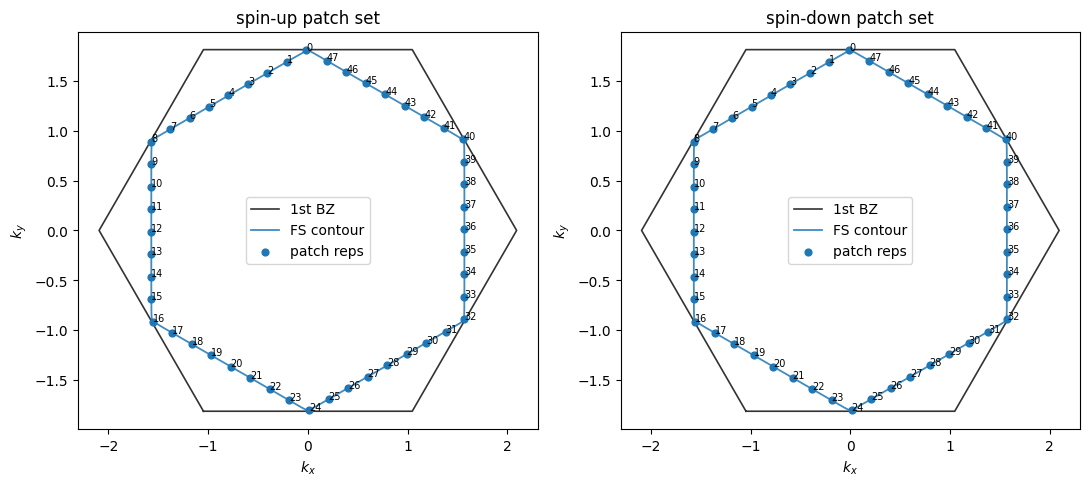

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_patchset(patchset_up, ax=axes[0], show_contour=True, show_velocity=False, show_bz=True)
axes[0].set_title('spin-up patch set')
plot_patchset(patchset_dn, ax=axes[1], show_contour=True, show_velocity=False, show_bz=True)
axes[1].set_title('spin-down patch set')
plt.tight_layout()
plt.show()

## 2. Construct the spin-conserving extended Hubbard interaction

In [7]:
hint = BareExtendedHubbard.from_kagome_model(model_up, U=2.0, V=0.6)
print(hint)

BareExtendedHubbard(U=2.0, V=0.6, delta1=array([0.5      , 0.8660254]), delta2=array([ 0.5      , -0.8660254]), delta3=array([-1.,  0.]))


## 3. Inspect orbital-basis kernels $W_{ab}(q)$ for different spin channels

In [15]:
q0 = np.array([0.0, 0.0])
W_udud = hint.orbital_interaction_matrix(q0, 'up', 'dn', 'up', 'dn')
W_uuuu = hint.orbital_interaction_matrix(q0, 'up', 'up', 'up', 'up')
W_uddu = hint.orbital_interaction_matrix(q0, 'up', 'dn', 'dn', 'up')  # spin-flip, should vanish

print('W_udud(q=0) =')
print(np.real_if_close(W_udud))
print('W_uuuu(q=0) =')
print(np.real_if_close(W_uuuu))
print('W_uddu(q=0) =')
print(np.real_if_close(W_uddu))

W_udud(q=0) =
[[2.  1.2 1.2]
 [1.2 2.  1.2]
 [1.2 1.2 2. ]]
W_uuuu(q=0) =
[[0.  1.2 1.2]
 [1.2 0.  1.2]
 [1.2 1.2 0. ]]
W_uddu(q=0) =
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


## 4. Test projected patch vertices

Here we check three basic facts:
1. onsite `U` contributes only in opposite-spin channel;
2. same-spin scattering can still be nonzero when `V != 0`;
3. spin-flip scattering vanishes.

In [18]:
hint_Uonly = BareExtendedHubbard.from_kagome_model(model_up, U=2.0, V=0.0)

p = 0
q = 6
r = 12
s = 18

val_U_udud = hint_Uonly.patch_vertex(patchsets, p, 'up', q, 'dn', r, 'up', s, 'dn')
val_U_uuuu = hint_Uonly.patch_vertex(patchsets, p, 'up', q, 'up', r, 'up', s, 'up')
val_U_uddu = hint_Uonly.patch_vertex(patchsets, p, 'up', q, 'dn', r, 'dn', s, 'up')

print('U-only, opposite spin  V(up,dn->up,dn) =', val_U_udud)
print('U-only, same spin      V(up,up->up,up) =', val_U_uuuu)
print('U-only, spin-flip      V(up,dn->dn,up) =', val_U_uddu)

U-only, opposite spin  V(up,dn->up,dn) = (-3.0171150321722644e-18+3.904404495628363e-18j)
U-only, same spin      V(up,up->up,up) = 0j
U-only, spin-flip      V(up,dn->dn,up) = 0j


In [20]:
val_full_udud = hint.patch_vertex(patchsets, p, 'up', q, 'dn', r, 'up', s, 'dn')
val_full_uuuu = hint.patch_vertex(patchsets, p, 'up', q, 'up', r, 'up', s, 'up')

print('U+V, opposite spin  =', val_full_udud)
print('U+V, same spin      =', val_full_uuuu)

U+V, opposite spin  = (7.112918534256371e-05-0.001212604306335748j)
U+V, same spin      = (7.112918534256672e-05-0.0012126043063357518j)


## 5. Quick table of patch data (spin up)

In [23]:
rows = []
for pt in patchset_up.patches:
    rows.append({
        'patch': pt.patch_id,
        'kx': pt.k_cart[0],
        'ky': pt.k_cart[1],
        'energy': pt.energy,
        'E-mu': pt.energy - patchset_up.mu,
        'wA': pt.orbital_weight[0],
        'wB': pt.orbital_weight[1],
        'wC': pt.orbital_weight[2],
    })
df = pd.DataFrame(rows)
df.head(12)

,patch,kx,ky,energy,E-mu,wA,wB,wC
0,0,-0.014008,1.805712,3.482842e-18,3.482842e-18,9.998038e-01,3.912938e-33,0.000196
1,1,-0.210145,1.692472,6.198839e-17,6.198839e-17,9.564852e-01,6.116972e-33,0.043515
2,2,-0.405475,1.579698,3.952045e-17,3.952045e-17,8.444051e-01,7.243235e-34,0.155595
3,3,-0.600813,1.466920,-1.747710e-16,-1.747710e-16,6.804208e-01,1.451142e-32,0.319579
4,4,-0.796153,1.354140,1.006140e-16,1.006140e-16,4.892456e-01,1.746326e-33,0.510754
5,5,-0.991494,1.241360,-1.512679e-15,-1.512679e-15,2.996911e-01,2.782939e-32,0.700309
6,6,-1.186833,1.128581,-6.245005e-16,-6.245005e-16,1.403239e-01,7.305645e-32,0.859676
7,7,-1.382167,1.015805,7.771561e-16,7.771561e-16,3.516091e-02,1.561181e-31,0.964839
8,8,-1.570796,0.891010,3.419778e-18,3.419778e-18,3.897084e-33,1.893402e-04,0.999811
9,9,-1.570796,0.664417,5.067392e-17,5.067392e-17,3.258046e-33,4.345381e-02,0.956546


## 6. Bare opposite-spin Cooper kernel

kernel shape = (48, 48)
max |Im K| = 0.019734607864050242


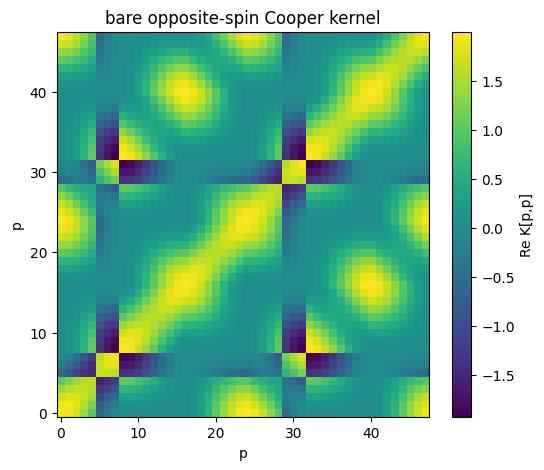

In [31]:
K = build_cooper_pairing_kernel(patchsets, hint, s1='up', s2='dn')
print('kernel shape =', K.shape)
print('max |Im K| =', np.max(np.abs(np.imag(K))))

plt.figure(figsize=(6,5))
plt.imshow(np.real(K), origin='lower', aspect='auto')
plt.colorbar(label='Re K[p,p]')
plt.title('bare opposite-spin Cooper kernel')
plt.xlabel('p')
plt.ylabel('p')
plt.show()

## Optional: how to switch this notebook to a Kane-Mele-type model

Replace the model constructors by something like:

```python
from noninteracting import KagomeKaneMeleSOC
model_up = KagomeKaneMeleSOC({'t':1.0, 'l1':+0.05, 'l2':+0.02}, spin=False)
model_dn = KagomeKaneMeleSOC({'t':1.0, 'l1':-0.05, 'l2':-0.02}, spin=False)
```

Then rebuild `patchset_up` and `patchset_dn` in exactly the same way.
The rewritten `interaction.py` does not care whether the spin dependence came from flux or intrinsic SOC, as long as the noninteracting model is **spin-conserving** and each spin sector can be patched separately as a 3-band problem.